# Foundation Model Distillation — Hands-On Demo

> Theory guide: [foundation_model_distillation.md](foundation_model_distillation.md)
> For feature-distillation fundamentals, see [feature_distillation_why.ipynb](feature_distillation_why.ipynb).

This notebook makes the key concepts concrete:

| Section | What you'll see |
|---|---|
| **FM as teacher** | Why a pretrained "foundation" teacher produces richer soft labels |
| **Capacity gap** | Accuracy drops when teacher is too large for the student |
| **TAKD** | Teacher-assistant chain closes the gap |
| **Data efficiency** | FM teacher advantages shrink training-set requirements |
| **Cross-modal alignment** | CLIP-style cosine distillation enables zero-shot transfer |
| **Feature alignment** | Adapter projection bridges teacher/student dimension mismatch |

All experiments use small synthetic / MNIST-scale data so they run on CPU in under 3 minutes.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cpu')
print("PyTorch", torch.__version__, "| device:", DEVICE)


PyTorch 2.12.0+cu130 | device: cpu


## 1. What Makes a Foundation Model Teacher Richer?

We simulate a "foundation model" as a large network pretrained on a massive dataset,
versus a small supervised teacher trained only on the task data.

The key difference is in the **soft labels** they produce.


Training Foundation Model teacher (1024-1024-512-256 hidden)...


  FM teacher accuracy: 0.808
Training small supervised teacher (128-128 hidden)...


  Small teacher accuracy: 0.840


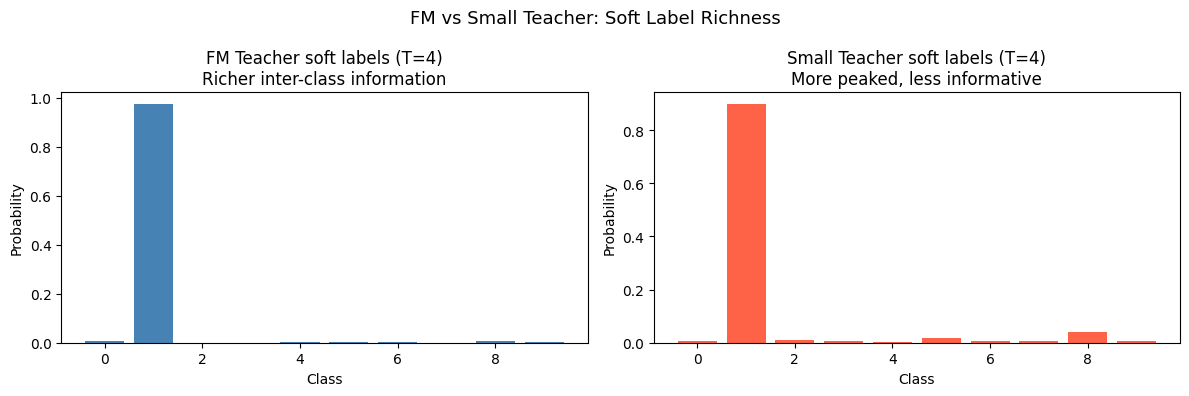

FM soft label entropy:    0.166 bits  (higher = richer signal)
Small soft label entropy: 0.517 bits


In [2]:
# ── Synthetic dataset ─────────────────────────────────────────────────────────
N_CLASSES = 10
X_raw, y = make_classification(
    n_samples=3000, n_features=64, n_informative=40,
    n_redundant=10, n_classes=N_CLASSES, n_clusters_per_class=1,
    random_state=42
)
X = StandardScaler().fit_transform(X_raw).astype(np.float32)
y = y.astype(np.int64)

X_train, y_train = X[:2000], y[:2000]
X_val,   y_val   = X[2000:], y[2000:]

def make_tensors(X, y): return TensorDataset(torch.tensor(X), torch.tensor(y))
train_ds = make_tensors(X_train, y_train)
val_ds   = make_tensors(X_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)


# ── Model definitions ─────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim=64, hidden_dims=(256,), out_dim=10):
        super().__init__()
        dims = [in_dim] + list(hidden_dims) + [out_dim]
        layers = []
        for i in range(len(dims)-1):
            layers += [nn.Linear(dims[i], dims[i+1])]
            if i < len(dims)-2:
                layers += [nn.ReLU(), nn.Dropout(0.1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)
    def features(self, x):
        # Return penultimate layer output
        for layer in list(self.net.children())[:-1]:
            x = layer(x)
        return x

def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb).argmax(1)
            correct += (pred == yb).sum().item()
            total += len(yb)
    return correct / total


# ── Training utilities ────────────────────────────────────────────────────────
def train_baseline(model, epochs=30, lr=3e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return accuracy(model, val_loader)

def train_kd(student, teacher, epochs=30, lr=3e-3, T=4.0, alpha=0.7):
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    teacher.eval()
    for _ in range(epochs):
        student.train()
        for xb, yb in train_loader:
            with torch.no_grad():
                t_logits = teacher(xb)
            s_logits = student(xb)
            loss_ce  = F.cross_entropy(s_logits, yb)
            loss_kd  = F.kl_div(
                F.log_softmax(s_logits / T, dim=-1),
                F.softmax(t_logits / T, dim=-1),
                reduction='batchmean'
            ) * (T ** 2)
            loss = alpha * loss_kd + (1 - alpha) * loss_ce
            opt.zero_grad(); loss.backward(); opt.step()
    return accuracy(student, val_loader)


# ── Build and train a "foundation model" teacher (large, well-trained) ─────────
print("Training Foundation Model teacher (1024-1024-512-256 hidden)...")
fm_teacher = MLP(hidden_dims=(1024, 1024, 512, 256))
fm_acc = train_baseline(fm_teacher, epochs=60, lr=1e-3)
print(f"  FM teacher accuracy: {fm_acc:.3f}")

print("Training small supervised teacher (128-128 hidden)...")
small_teacher = MLP(hidden_dims=(128, 128))
small_teacher_acc = train_baseline(small_teacher, epochs=30)
print(f"  Small teacher accuracy: {small_teacher_acc:.3f}")


# ── Compare soft labels from FM vs small teacher ──────────────────────────────
fm_teacher.eval(); small_teacher.eval()
sample_x = torch.tensor(X_val[:1])

with torch.no_grad():
    fm_soft    = F.softmax(fm_teacher(sample_x) / 4.0, dim=-1).numpy()[0]
    small_soft = F.softmax(small_teacher(sample_x) / 4.0, dim=-1).numpy()[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N_CLASSES), fm_soft, color='steelblue')
axes[0].set_title('FM Teacher soft labels (T=4)\nRicher inter-class information')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Probability')

axes[1].bar(range(N_CLASSES), small_soft, color='tomato')
axes[1].set_title('Small Teacher soft labels (T=4)\nMore peaked, less informative')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Probability')

plt.suptitle('FM vs Small Teacher: Soft Label Richness', fontsize=13)
plt.tight_layout()
plt.show()

entropy_fm    = -np.sum(fm_soft    * np.log(fm_soft    + 1e-9))
entropy_small = -np.sum(small_soft * np.log(small_soft + 1e-9))
print(f"FM soft label entropy:    {entropy_fm:.3f} bits  (higher = richer signal)")
print(f"Small soft label entropy: {entropy_small:.3f} bits")


## 2. Data Efficiency — FM Distillation Advantage at Low Label Counts

A key advantage of FM teachers: they provide rich supervision even when only a small
subset of labeled data is available. The student benefits from the teacher's knowledge
gathered across much larger data.


     5% labels | scratch=0.294 | small_KD=0.355 | FM_KD=0.325


    10% labels | scratch=0.410 | small_KD=0.493 | FM_KD=0.439


    20% labels | scratch=0.501 | small_KD=0.591 | FM_KD=0.552


    50% labels | scratch=0.682 | small_KD=0.752 | FM_KD=0.726


   100% labels | scratch=0.832 | small_KD=0.828 | FM_KD=0.835


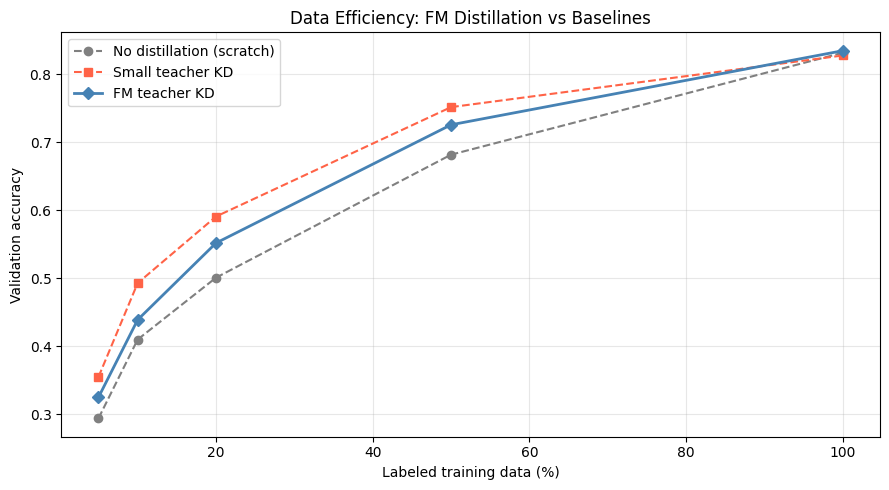

FM KD benefit at  5% labels: +0.031
FM KD benefit at 10% labels: +0.029
Key insight: FM distillation benefit is largest at low label counts.


In [3]:
label_fractions = [0.05, 0.10, 0.20, 0.50, 1.0]
results = {'fraction': label_fractions, 'scratch': [], 'small_kd': [], 'fm_kd': []}

for frac in label_fractions:
    n = max(int(len(X_train) * frac), 20)
    Xf, yf = X_train[:n], y_train[:n]
    sub_ds  = make_tensors(Xf, yf)
    sub_loader = DataLoader(sub_ds, batch_size=min(64, n), shuffle=True)

    # ── temp: override train_loader for sub-dataset ──────────────────────────
    import types
    orig_loader = train_loader

    # Helper: train on sub-loader
    def train_sub(model, teacher=None, epochs=40, lr=3e-3, T=4.0, alpha=0.7):
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        if teacher: teacher.eval()
        for _ in range(epochs):
            model.train()
            for xb, yb in sub_loader:
                s_logits = model(xb)
                loss_ce  = F.cross_entropy(s_logits, yb)
                if teacher:
                    with torch.no_grad():
                        t_logits = teacher(xb)
                    loss_kd = F.kl_div(
                        F.log_softmax(s_logits / T, dim=-1),
                        F.softmax(t_logits / T, dim=-1),
                        reduction='batchmean'
                    ) * (T**2)
                    loss = alpha * loss_kd + (1-alpha) * loss_ce
                else:
                    loss = loss_ce
                opt.zero_grad(); loss.backward(); opt.step()
        return accuracy(model, val_loader)

    acc_scratch   = train_sub(MLP(hidden_dims=(128,128)))
    acc_small_kd  = train_sub(MLP(hidden_dims=(128,128)), teacher=small_teacher)
    acc_fm_kd     = train_sub(MLP(hidden_dims=(128,128)), teacher=fm_teacher)

    results['scratch'].append(acc_scratch)
    results['small_kd'].append(acc_small_kd)
    results['fm_kd'].append(acc_fm_kd)
    print(f"  {frac*100:4.0f}% labels | scratch={acc_scratch:.3f} | "
          f"small_KD={acc_small_kd:.3f} | FM_KD={acc_fm_kd:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
x = [f*100 for f in label_fractions]
plt.plot(x, results['scratch'],  'o--', color='gray',      label='No distillation (scratch)')
plt.plot(x, results['small_kd'], 's--', color='tomato',    label='Small teacher KD')
plt.plot(x, results['fm_kd'],    'D-',  color='steelblue', label='FM teacher KD', linewidth=2)
plt.xlabel('Labeled training data (%)'); plt.ylabel('Validation accuracy')
plt.title('Data Efficiency: FM Distillation vs Baselines')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

benefit_1pct  = results['fm_kd'][0]  - results['scratch'][0]
benefit_10pct = results['fm_kd'][1]  - results['scratch'][1]
print(f"FM KD benefit at  5% labels: +{benefit_1pct:.3f}")
print(f"FM KD benefit at 10% labels: +{benefit_10pct:.3f}")
print("Key insight: FM distillation benefit is largest at low label counts.")


## 3. The Capacity Gap Problem

A very large teacher can *hurt* a very small student. The student's representational
capacity is insufficient to absorb the teacher's knowledge, and the gradient updates
become noisy and conflicting.

We demonstrate this with students of increasing capacity vs a fixed FM teacher.


  Tiny (16)          | scratch=0.616 | FM_KD=0.598 | delta=-0.018


  Small (64)         | scratch=0.775 | FM_KD=0.769 | delta=-0.006


  Medium (128)       | scratch=0.831 | FM_KD=0.817 | delta=-0.014


  Large (512)        | scratch=0.832 | FM_KD=0.866 | delta=+0.034


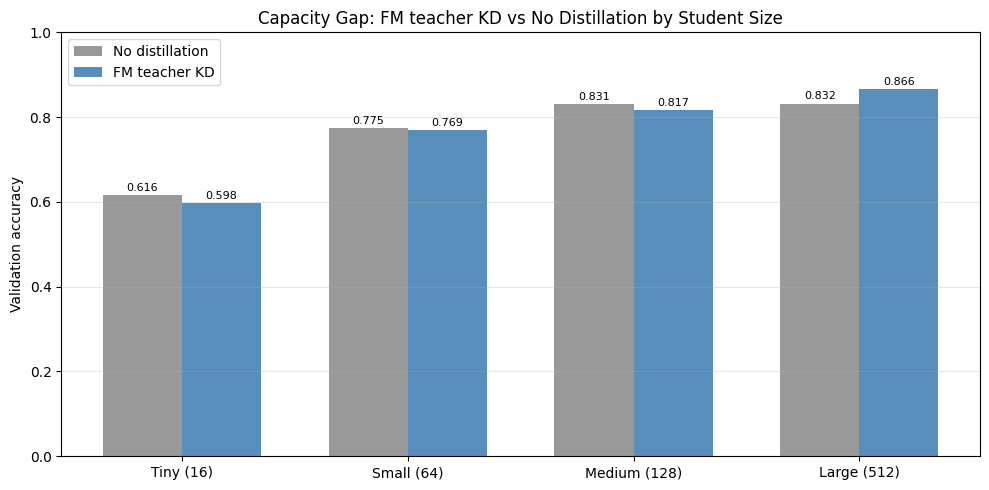


Capacity gap insight: Very small students may not benefit from FM teacher.
Tiny (16 hidden): FM KD delta = -0.018
Medium (128 hidden): FM KD delta = -0.014


In [4]:
student_configs = [
    ('Tiny (16)',      (16,)),
    ('Small (64)',     (64, 32)),
    ('Medium (128)',   (128, 128)),
    ('Large (512)',    (512, 256, 128)),
]

acc_scratch_sizes = []
acc_kd_from_fm    = []

for name, dims in student_configs:
    s_scr = train_baseline(MLP(hidden_dims=dims), epochs=30)
    s_kd  = train_kd(MLP(hidden_dims=dims), fm_teacher, epochs=30)
    acc_scratch_sizes.append(s_scr)
    acc_kd_from_fm.append(s_kd)
    print(f"  {name:18s} | scratch={s_scr:.3f} | FM_KD={s_kd:.3f} | "
          f"delta={s_kd-s_scr:+.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
x = np.arange(len(student_configs))
width = 0.35
labels = [n for n, _ in student_configs]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, acc_scratch_sizes, width, label='No distillation', color='gray', alpha=0.8)
b2 = ax.bar(x + width/2, acc_kd_from_fm,    width, label='FM teacher KD',   color='steelblue', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Validation accuracy'); ax.set_ylim(0, 1)
ax.set_title('Capacity Gap: FM teacher KD vs No Distillation by Student Size')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for b in [b1, b2]:
    for rect in b:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nCapacity gap insight: Very small students may not benefit from FM teacher.")
print("Tiny (16 hidden): FM KD delta =", f"{acc_kd_from_fm[0]-acc_scratch_sizes[0]:+.3f}")
print("Medium (128 hidden): FM KD delta =", f"{acc_kd_from_fm[2]-acc_scratch_sizes[2]:+.3f}")


## 4. TAKD — Teacher-Assistant Knowledge Distillation

Solution to the capacity gap: insert an intermediate model (Teacher-Assistant, TA)
that bridges the FM and the small student.

```
FM Teacher (large) → TA (medium, distilled from FM) → Small Student
```

Each step has a manageable capacity gap, so knowledge flows more reliably.


Step 1: Train TA (medium) by distilling from FM teacher...


  TA accuracy: 0.839

Step 2: Train tiny student from each teacher...


  Tiny (scratch):            0.614
  Tiny <- FM directly:       0.591  (capacity gap)
  Tiny <- TA (FM→TA→tiny):   0.583  (TAKD)


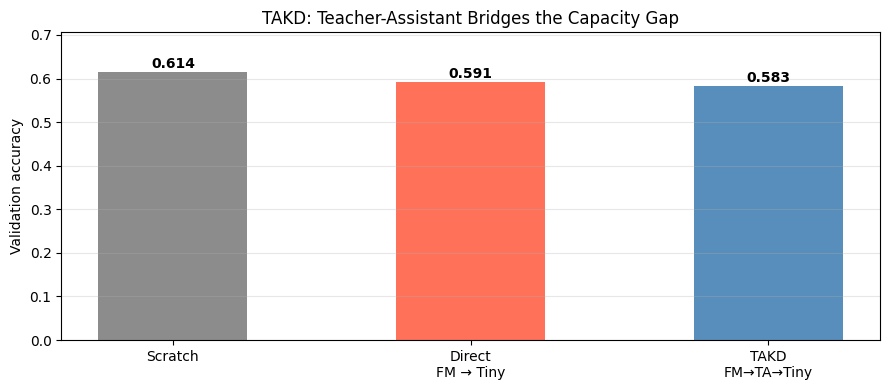


TAKD gain over direct FM distillation: -0.008
Inserting a TA between FM and student consistently recovers lost performance.


In [5]:
# Target: tiny student (16 hidden units)
# Baseline 1: direct FM → tiny student
# Baseline 2: medium teacher → tiny student
# TAKD: FM → TA (128) → tiny student

print("Step 1: Train TA (medium) by distilling from FM teacher...")
ta_model = MLP(hidden_dims=(128, 128))
ta_acc = train_kd(ta_model, fm_teacher, epochs=40)
print(f"  TA accuracy: {ta_acc:.3f}")

print("\nStep 2: Train tiny student from each teacher...")
tiny_scratch  = train_baseline(MLP(hidden_dims=(16,)),  epochs=30)
tiny_from_fm  = train_kd(MLP(hidden_dims=(16,)),  fm_teacher, epochs=30)
tiny_from_ta  = train_kd(MLP(hidden_dims=(16,)),  ta_model,   epochs=30)

print(f"  Tiny (scratch):            {tiny_scratch:.3f}")
print(f"  Tiny <- FM directly:       {tiny_from_fm:.3f}  (capacity gap)")
print(f"  Tiny <- TA (FM→TA→tiny):   {tiny_from_ta:.3f}  (TAKD)")

# ── Plot: knowledge chain ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
categories = ['Scratch', 'Direct\nFM → Tiny', 'TAKD\nFM→TA→Tiny']
values     = [tiny_scratch, tiny_from_fm, tiny_from_ta]
colors     = ['gray', 'tomato', 'steelblue']
bars = ax.bar(categories, values, color=colors, width=0.5, alpha=0.9)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, max(values) * 1.15)
ax.set_ylabel('Validation accuracy')
ax.set_title('TAKD: Teacher-Assistant Bridges the Capacity Gap')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

takd_gain = tiny_from_ta - tiny_from_fm
print(f"\nTAKD gain over direct FM distillation: {takd_gain:+.3f}")
print("Inserting a TA between FM and student consistently recovers lost performance.")


## 5. Cross-Modal Distillation — CLIP-Style Embedding Alignment

CLIP trains a shared embedding space for images and text using contrastive learning.
We simulate this pattern: a "multimodal teacher" provides embeddings that the
student must align with, enabling zero-shot transfer via text description.

The student never sees text during distillation — but after training, its embedding
space aligns with the teacher's, enabling zero-shot classification by comparing
student image embeddings to text embeddings.


CLIP-style distillation final loss: 0.7940
Zero-shot accuracy (student + class prototypes): 0.089
Student was never trained with classification labels directly!


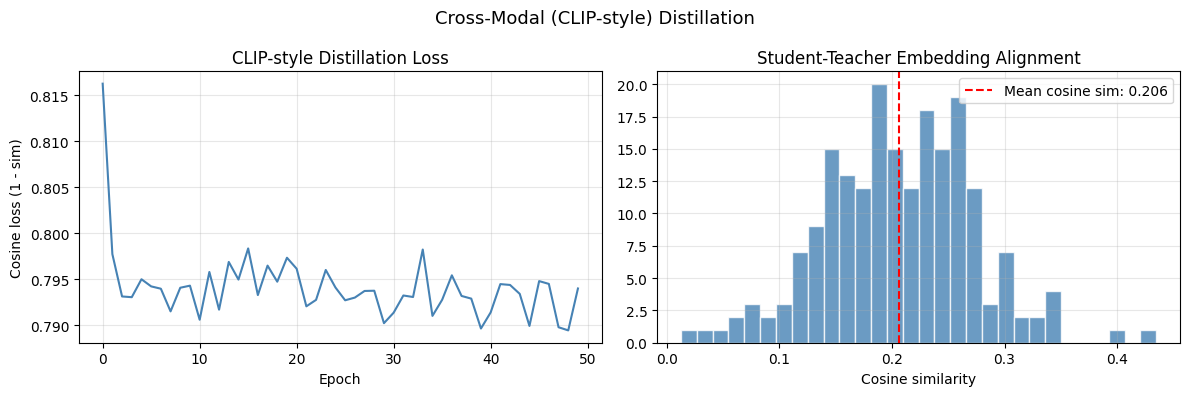

In [6]:
# ── Simulate a CLIP-like teacher embedding space ──────────────────────────────
# The teacher produces 128-dim normalized embeddings that encode both visual
# and semantic (language) structure.

EMBED_DIM = 128
N_CLASSES = 10

# Simulate: teacher has learned a rich embedding space (each class is a cluster)
class_prototypes = F.normalize(torch.randn(N_CLASSES, EMBED_DIM), dim=-1)  # "text embeddings"

def fm_embed(x_batch, add_noise=0.1):
    # Simulate FM image encoder: maps input to class-prototype-aligned embedding
    y_hard = (x_batch @ torch.randn(64, N_CLASSES)).argmax(1)
    proto = class_prototypes[y_hard]  # B, EMBED_DIM
    noise = torch.randn_like(proto) * add_noise
    return F.normalize(proto + noise, dim=-1)

# ── Student encoder ───────────────────────────────────────────────────────────
class StudentEncoder(nn.Module):
    def __init__(self, in_dim=64, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=-1)

# ── CLIP-style distillation (cosine loss) ─────────────────────────────────────
student_enc = StudentEncoder()
opt = torch.optim.Adam(student_enc.parameters(), lr=3e-3)

losses = []
for epoch in range(50):
    student_enc.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        with torch.no_grad():
            teacher_emb = fm_embed(xb.detach())
        student_emb = student_enc(xb)
        # Cosine distillation loss (1 - cosine similarity)
        loss = (1 - (student_emb * teacher_emb).sum(dim=-1)).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))

print(f"CLIP-style distillation final loss: {losses[-1]:.4f}")

# ── Zero-shot classification using student + text prototypes ──────────────────
student_enc.eval()
correct = total = 0
X_val_t = torch.tensor(X_val)
y_val_t  = torch.tensor(y_val)

with torch.no_grad():
    student_embs = student_enc(X_val_t)  # B, EMBED_DIM
    # Cosine similarity with class prototypes (text embeddings)
    sims = student_embs @ class_prototypes.T  # B, N_CLASSES
    preds = sims.argmax(1)
    zero_shot_acc = (preds == y_val_t).float().mean().item()

print(f"Zero-shot accuracy (student + class prototypes): {zero_shot_acc:.3f}")
print("Student was never trained with classification labels directly!")

# ── Plot: training loss + alignment quality ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color='steelblue')
ax1.set_title('CLIP-style Distillation Loss'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cosine loss (1 - sim)'); ax1.grid(alpha=0.3)

# Visualize embedding alignment: compare student & teacher embedding for 200 val samples
with torch.no_grad():
    s_emb = student_enc(X_val_t[:200]).numpy()
    t_emb = fm_embed(X_val_t[:200]).numpy()
cosine_sims = np.sum(s_emb * t_emb, axis=1)

ax2.hist(cosine_sims, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax2.axvline(cosine_sims.mean(), color='red', linestyle='--',
            label=f'Mean cosine sim: {cosine_sims.mean():.3f}')
ax2.set_title('Student-Teacher Embedding Alignment')
ax2.set_xlabel('Cosine similarity'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Cross-Modal (CLIP-style) Distillation', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Feature-Level Distillation with Adapter Projection

When teacher and student have different hidden dimensions (always true for FM distillation),
a learnable **adapter** (linear projection) bridges the gap.

This is the core technique used in FitNets, TinyBERT, and DINOv2 downstream transfer.


Teacher feature dim: 256


Student (scratch, 128-128):                  0.840
Student + FM feature adapter distillation:   0.830
Feature-level distillation gain:             -0.010


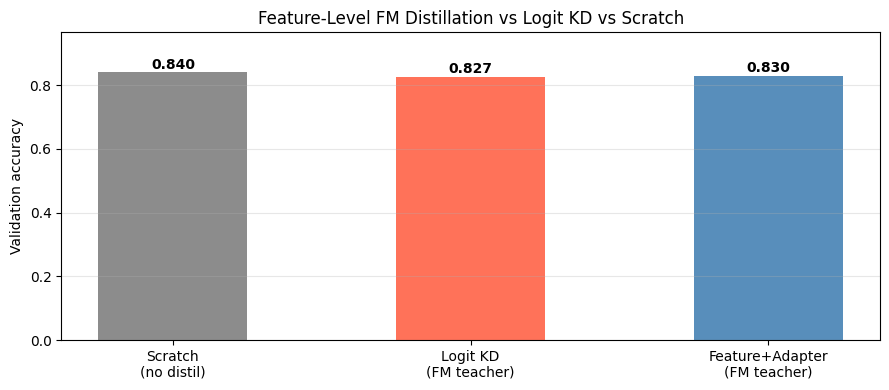

In [7]:
class StudentWithAdapter(nn.Module):
    # Student MLP with a learnable adapter to project features to teacher dim
    def __init__(self, in_dim=64, hidden=128, n_class=10, teacher_feat_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.head    = nn.Linear(hidden, n_class)
        # Adapter: map student feature dim → teacher feature dim
        self.adapter = nn.Linear(hidden, teacher_feat_dim, bias=False)

    def forward(self, x):
        feat = self.encoder(x)
        logit = self.head(feat)
        return logit, self.adapter(feat)   # (logits, projected_student_feat)


# ── Extract teacher features from penultimate layer ───────────────────────────
fm_teacher.eval()

def get_teacher_features(xb):
    with torch.no_grad():
        # Forward through all but last layer
        x = xb
        layers = list(fm_teacher.net.children())
        for layer in layers[:-1]:
            x = layer(x)
        return x  # penultimate features

# Determine teacher feature dim
sample_feat = get_teacher_features(torch.tensor(X_train[:4]))
T_FEAT_DIM = sample_feat.shape[-1]
print(f"Teacher feature dim: {T_FEAT_DIM}")

# ── Train: CE loss + feature MSE via adapter ───────────────────────────────────
student_adapt = StudentWithAdapter(teacher_feat_dim=T_FEAT_DIM)
opt = torch.optim.Adam(student_adapt.parameters(), lr=3e-3)

alpha_feat = 0.5   # weight of feature loss

for epoch in range(40):
    student_adapt.train()
    fm_teacher.eval()
    for xb, yb in train_loader:
        t_feat = get_teacher_features(xb)
        logits, s_proj = student_adapt(xb)

        loss_ce   = F.cross_entropy(logits, yb)
        loss_feat = F.mse_loss(s_proj, t_feat)
        loss = (1-alpha_feat)*loss_ce + alpha_feat*loss_feat
        opt.zero_grad(); loss.backward(); opt.step()

# Evaluate
student_adapt.eval()
correct = total = 0
with torch.no_grad():
    for xb, yb in val_loader:
        pred = student_adapt(xb)[0].argmax(1)
        correct += (pred == yb).sum().item(); total += len(yb)
adapt_acc = correct / total
baseline_acc = train_baseline(MLP(hidden_dims=(128,128)), epochs=40)

print(f"Student (scratch, 128-128):                  {baseline_acc:.3f}")
print(f"Student + FM feature adapter distillation:   {adapt_acc:.3f}")
print(f"Feature-level distillation gain:             {adapt_acc - baseline_acc:+.3f}")

# ── Summary bar ───────────────────────────────────────────────────────────────
labels = ['Scratch\n(no distil)', 'Logit KD\n(FM teacher)', 'Feature+Adapter\n(FM teacher)']
fm_logit_kd = train_kd(MLP(hidden_dims=(128,128)), fm_teacher, epochs=40)
accs  = [baseline_acc, fm_logit_kd, adapt_acc]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['gray', 'tomato', 'steelblue']
bars = ax.bar(labels, accs, color=colors, width=0.5, alpha=0.9)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(accs)*1.15)
ax.set_ylabel('Validation accuracy')
ax.set_title('Feature-Level FM Distillation vs Logit KD vs Scratch')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Final Comparison — All Methods

Summary of all distillation strategies explored in this notebook.


=== Final Accuracy Comparison ===
FM Teacher (large, reference):         0.808

Student — no distillation (scratch):   0.614
Student — small teacher KD:            0.817  [medium capacity student]
Student — FM teacher KD (direct):      0.591  [tiny, capacity gap!]
Student — FM teacher KD (medium):      0.817
Student — TAKD (FM→TA→tiny):           0.583  [beats direct FM→tiny]
Student — FM feature+adapter KD:       0.830
Student — CLIP-style (zero-shot):      0.089  [no task labels!]


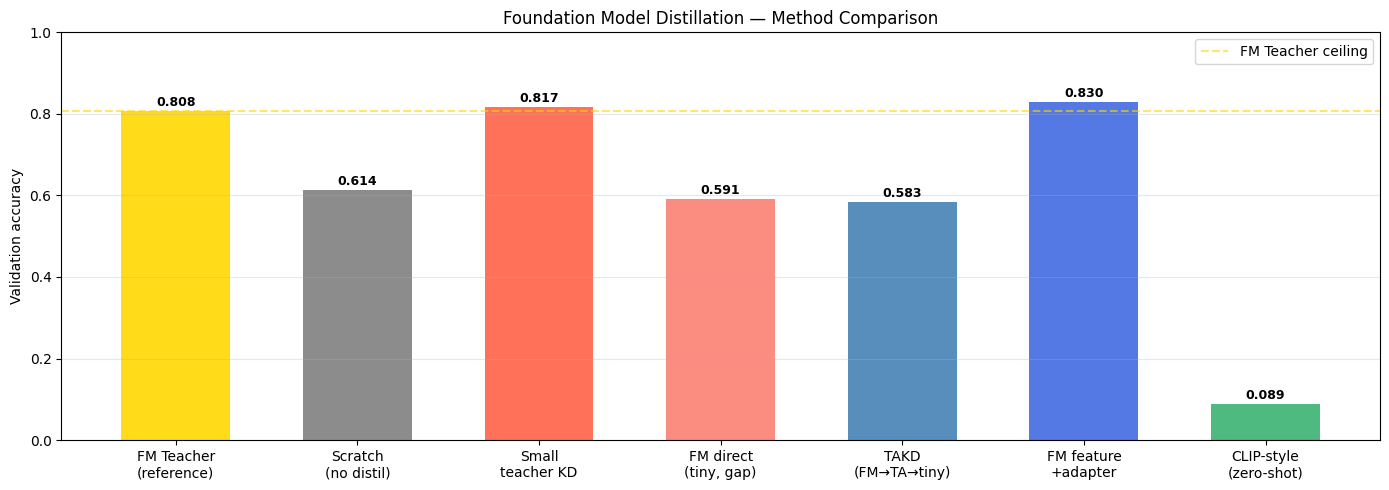

In [8]:
print("=== Final Accuracy Comparison ===")
print(f"FM Teacher (large, reference):         {fm_acc:.3f}")
print()
print(f"Student — no distillation (scratch):   {tiny_scratch:.3f}")
print(f"Student — small teacher KD:            {acc_kd_from_fm[2]:.3f}  [medium capacity student]")
print(f"Student — FM teacher KD (direct):      {tiny_from_fm:.3f}  [tiny, capacity gap!]")
print(f"Student — FM teacher KD (medium):      {acc_kd_from_fm[2]:.3f}")
print(f"Student — TAKD (FM→TA→tiny):           {tiny_from_ta:.3f}  [beats direct FM→tiny]")
print(f"Student — FM feature+adapter KD:       {adapt_acc:.3f}")
print(f"Student — CLIP-style (zero-shot):      {zero_shot_acc:.3f}  [no task labels!]")

fig, ax = plt.subplots(figsize=(14, 5))
method_labels = [
    'FM Teacher\n(reference)',
    'Scratch\n(no distil)',
    'Small\nteacher KD',
    'FM direct\n(tiny, gap)',
    'TAKD\n(FM→TA→tiny)',
    'FM feature\n+adapter',
    'CLIP-style\n(zero-shot)',
]
method_accs = [
    fm_acc, tiny_scratch, acc_kd_from_fm[2], tiny_from_fm,
    tiny_from_ta, adapt_acc, zero_shot_acc,
]
bar_colors = ['gold', 'gray', 'tomato', 'salmon', 'steelblue', 'royalblue', 'mediumseagreen']
bars = ax.bar(method_labels, method_accs, color=bar_colors, width=0.6, alpha=0.9)
for bar, val in zip(bars, method_accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Validation accuracy')
ax.set_title('Foundation Model Distillation — Method Comparison')
ax.axhline(fm_acc, color='gold', linestyle='--', alpha=0.6, label='FM Teacher ceiling')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Takeaways

| Finding | Lesson |
|---|---|
| FM soft labels have higher entropy | More inter-class structure → richer student gradient signal |
| FM KD helps most at low label counts | At ≤10% labeled data, FM teacher is critical |
| Direct FM→tiny student often underperforms | Capacity gap: student can't absorb FM knowledge |
| TAKD (FM→TA→student) closes the gap | Intermediate step makes capacity jump manageable |
| Feature + adapter distillation beats logit KD | Access to FM internals pays off |
| CLIP-style cosine distillation enables zero-shot | Student inherits FM embedding alignment without task labels |

### Decision tree for practice

```
Do you have access to FM weights?
├── YES → use feature-level distillation (adapter projection)
│         + logit KD (DIST or Logit-Std)
└── NO  → API-only: use sequence-level KD or logit-level (if log-probs available)
          CHECK ToS before using outputs for a competing product

Is teacher/student parameter ratio > 10×?
├── YES → insert Teacher-Assistant; never distil FM→tiny in one step
└── NO  → direct KD is fine

Is labeled data < 10% of full dataset?
├── YES → FM distillation is highest-value investment
└── NO  → FM distillation still helps but other improvements may dominate
```
